# Stellar Class — Baseline LightGBM
**Kaggle Playground Series S6E6**

Цель: обучить первую модель и получить сабмит на Kaggle

Метрика: Balanced Accuracy

## 1. Импорты

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
N_FOLDS = 5

print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Загрузка данных

In [4]:
train = pd.read_csv('../data/raw/train.csv')
test  = pd.read_csv('../data/raw/test.csv')

print(f'Train: {train.shape}')
print(f'Test:  {test.shape}')

Train: (577347, 12)
Test:  (247435, 11)


## 3. Feature Engineering

Создаём новые фичи на основе выводов из EDA:
- Цветовые индексы (разности диапазонов)
- Трансформация redshift
- Interaction terms

In [5]:
def engineer_features(df):
    df = df.copy()
    
    # Цветовые индексы — разности между SDSS диапазонами
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_r'] = df['u'] - df['r']
    df['u_z'] = df['u'] - df['z']
    df['g_z'] = df['g'] - df['z']
    df['g_i'] = df['g'] - df['i']
    
    # Trансформация redshift
    df['log1p_redshift'] = np.log1p(df['redshift'].clip(lower=0))
    df['redshift_sq']    = df['redshift'] ** 2
    
    # Interaction terms
    df['u_g_x_redshift'] = df['u_g'] * df['log1p_redshift']
    df['g_r_x_redshift'] = df['g_r'] * df['log1p_redshift']
    
    return df

train = engineer_features(train)
test  = engineer_features(test)

print(f'Фичей после engineering: {train.shape[1]}')
print('Новые фичи:', [c for c in train.columns if c not in ['id','alpha','delta','u','g','r','i','z','redshift','spectral_type','galaxy_population','class']])

Фичей после engineering: 24
Новые фичи: ['u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'u_z', 'g_z', 'g_i', 'log1p_redshift', 'redshift_sq', 'u_g_x_redshift', 'g_r_x_redshift']


## 4. Кодирование категориальных переменных

LabelEncoder превращает текст в числа:
- M → 0, A/F → 1, G/K → 2, O/B → 3
- Red_Sequence → 0, Blue_Cloud → 1

In [6]:
cat_cols = ['spectral_type', 'galaxy_population']

for col in cat_cols:
    le = LabelEncoder()
    # fit на объединённых данных — чтобы test не содержал неизвестных значений
    le.fit(pd.concat([train[col], test[col]]))
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\nКодирование завершено ✅')

spectral_type: {'A/F': np.int64(0), 'G/K': np.int64(1), 'M': np.int64(2), 'O/B': np.int64(3)}
galaxy_population: {'Blue_Cloud': np.int64(0), 'Red_Sequence': np.int64(1)}

Кодирование завершено ✅


## 5. Подготовка данных для модели

In [7]:
# Колонки которые не используем
DROP_COLS = ['id', 'class', 'alpha', 'delta']  
# alpha и delta — координаты, из EDA видно что они не информативны

FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]
TARGET_COL   = 'class'

X = train[FEATURE_COLS]
y = train[TARGET_COL]
X_test = test[FEATURE_COLS]

print(f'Фичей для модели: {len(FEATURE_COLS)}')
print(f'Список фичей: {FEATURE_COLS}')

Фичей для модели: 20
Список фичей: ['u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'u_z', 'g_z', 'g_i', 'log1p_redshift', 'redshift_sq', 'u_g_x_redshift', 'g_r_x_redshift']


## 6. Кодирование целевой переменной

LightGBM требует числовой таргет для multiclass

In [8]:
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print('Классы:', dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))
# Запоминаем для декодирования предсказаний

Классы: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}


## 7. Обучение модели — Stratified K-Fold

**Зачем K-Fold?**

Делим train на 5 частей. Обучаем 5 моделей — каждый раз на 4 частях, проверяем на 1-й. 
Так получаем честную оценку качества без утечки данных.

**Зачем Stratified?**

Сохраняет пропорцию классов в каждом fold — важно при дисбалансе.

In [10]:
# Параметры LightGBM
lgb_params = {
    'objective':        'multiclass',   # задача классификации 3 класса
    'num_class':        3,              # количество классов
    'metric':           'multi_logloss',
    'n_estimators':     1000,           # максимум деревьев (early stopping остановит раньше)
    'learning_rate':    0.05,           # размер шага
    'num_leaves':       63,             # сложность каждого дерева
    'min_child_samples': 20,            # защита от переобучения
    'subsample':        0.8,            # случайная выборка строк для каждого дерева
    'colsample_bytree': 0.8,            # случайная выборка фичей
    'random_state':     RANDOM_STATE,
    'verbose':          -1,
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_preds   = np.zeros((len(train), 3))   # out-of-fold предсказания
test_preds  = np.zeros((len(test), 3))    # предсказания на test
cv_scores   = []

print(f'Обучаем {N_FOLDS}-fold CV...\n')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_encoded)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
    
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),   # стоп если нет улучшения 50 итераций
            lgb.log_evaluation(period=200)           # печатаем прогресс каждые 200 итераций
        ]
    )
    
    # Предсказания на валидации
    val_proba  = model.predict_proba(X_val)
    val_preds  = np.argmax(val_proba, axis=1)
    score      = balanced_accuracy_score(y_val, val_preds)
    cv_scores.append(score)
    
    # Сохраняем OOF и test предсказания
    oof_preds[val_idx]  = val_proba
    test_preds         += model.predict_proba(X_test) / N_FOLDS
    
    print(f'Fold {fold+1} | Balanced Accuracy: {score:.5f} | Деревьев: {model.best_iteration_}')

print(f'\n=== CV Score: {np.mean(cv_scores):.5f} ± {np.std(cv_scores):.5f} ===')

Обучаем 5-fold CV...

[200]	valid_0's multi_logloss: 0.120995
Fold 1 | Balanced Accuracy: 0.93681 | Деревьев: 161
[200]	valid_0's multi_logloss: 0.12576
Fold 2 | Balanced Accuracy: 0.93754 | Деревьев: 163
[200]	valid_0's multi_logloss: 0.134544
Fold 3 | Balanced Accuracy: 0.93662 | Деревьев: 155
[200]	valid_0's multi_logloss: 0.120803
Fold 4 | Balanced Accuracy: 0.93782 | Деревьев: 250
[200]	valid_0's multi_logloss: 0.122979
Fold 5 | Balanced Accuracy: 0.93729 | Деревьев: 154

=== CV Score: 0.93721 ± 0.00044 ===


## 8. OOF Score — финальная оценка

In [11]:
oof_classes = np.argmax(oof_preds, axis=1)
oof_score   = balanced_accuracy_score(y_encoded, oof_classes)
print(f'OOF Balanced Accuracy: {oof_score:.5f}')
print('\nЭто наш ориентир — LB score должен быть близок к этому числу')

OOF Balanced Accuracy: 0.93721

Это наш ориентир — LB score должен быть близок к этому числу


## 9. Feature Importance — какие фичи важны

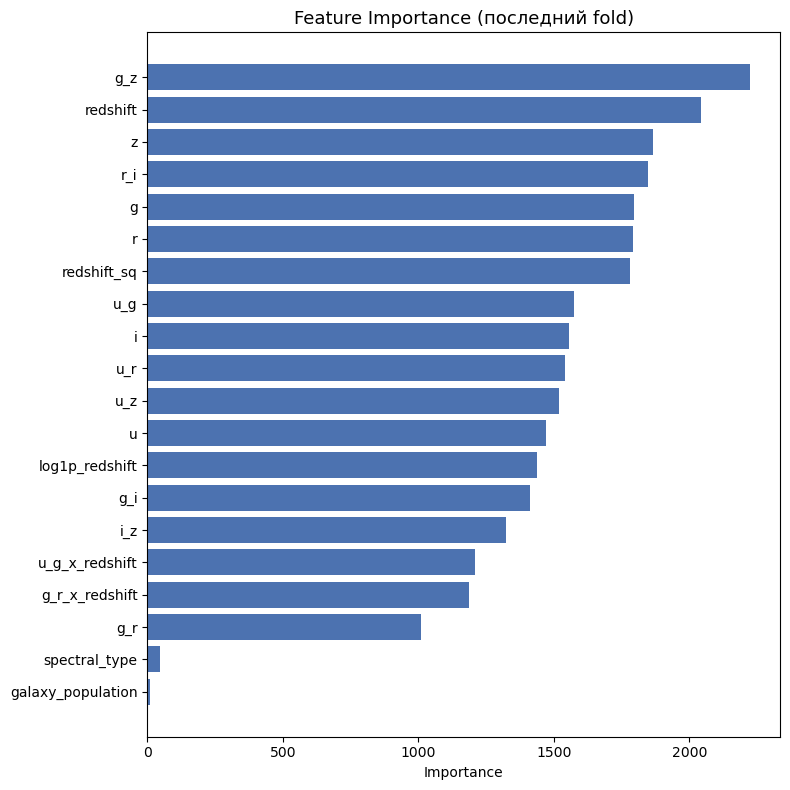


Топ-5 фичей:
 feature  importance
     g_z        2223
redshift        2044
       z        1865
     r_i        1847
       g        1797


In [12]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(importance['feature'], importance['importance'], color='#4C72B0')
ax.set_title('Feature Importance (последний fold)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nТоп-5 фичей:')
print(importance.tail(5)[['feature','importance']].iloc[::-1].to_string(index=False))

## 10. Создание файла для сабмита

In [14]:
# Декодируем числа обратно в названия классов
test_classes = np.argmax(test_preds, axis=1)
test_labels  = le_target.inverse_transform(test_classes)

submission = pd.DataFrame({
    'id':    test['id'],
    'class': test_labels
})

submission.to_csv('../submissions/submission_v1_baseline.csv', index=False)

print('Сабмит сохранён ✅')
print(f'Строк: {len(submission)}')
print('\nРаспределение предсказаний:')
print(submission['class'].value_counts())
print('\nПервые 5 строк:')
print(submission.head())

Сабмит сохранён ✅
Строк: 247435

Распределение предсказаний:
class
GALAXY    162166
QSO        50261
STAR       35008
Name: count, dtype: int64

Первые 5 строк:
       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY


## 11. Итоги

**Что сделали:**
- Feature engineering: 8 цветовых индексов + log redshift + interactions
- Label Encoding категориальных фич
- Stratified 5-Fold CV
- LightGBM с early stopping

**Следующие шаги для улучшения скора:**
- Добавить XGBoost и CatBoost → ensemble
- Попробовать Target Encoding